In [1]:
from langgraph.graph import StateGraph,START,END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [2]:
class CrashState(TypedDict):
    input : str
    step1 : str
    step2 : str
    step3 : str    

In [3]:
def step1(state:CrashState) -> CrashState:
    print("Step1 Executed")
    return {'step1':'Done','input':state['input']}

def step2(state:CrashState) -> CrashState:
    print("Step2 Hanging ... now mannualy interrupt from notebook toolbar (Stop Button)")
    time.sleep(30)
    return {'step2':'Done'}

def step3(state:CrashState) -> CrashState:
    print("Step3 Executed")
    return {'step3','Done'}

In [4]:
builder = StateGraph(CrashState)

builder.add_node('step1',step1)
builder.add_node('step2',step2)
builder.add_node('step3',step3)

builder.add_edge(START,'step1')
builder.add_edge('step1','step2')
builder.add_edge('step2','step3')
builder.add_edge('step3',END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

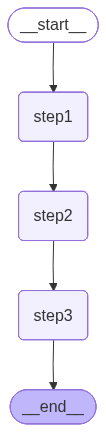

In [5]:
graph

In [6]:
try:
    print('Running Graph : Please manually interrupt during step2...')
    graph.invoke({'input':'start'},config={'configurable':{'thread_id':'thread-1'}})
except KeyboardInterrupt:
    print('Kernel manually interrupted (crash simulated)')

Running Graph : Please manually interrupt during step2...
Step1 Executed
Step2 Hanging ... now mannualy interrupt from notebook toolbar (Stop Button)
Kernel manually interrupted (crash simulated)


In [7]:
graph.get_state({'configurable':{'thread_id':'thread-1'}})

StateSnapshot(values={'input': 'start', 'step1': 'Done'}, next=('step2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f14e23b-17d0-63de-8001-4d305c46d710'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-05-12T16:57:43.377798+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f14e23b-17cc-63b2-8000-7320e44afb13'}}, tasks=(PregelTask(id='c83dff21-ef27-a5ca-1f49-5b3c859b78fa', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [8]:
list(graph.get_state_history({'configurable':{'thread_id':'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'Done'}, next=('step2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f14e23b-17d0-63de-8001-4d305c46d710'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-05-12T16:57:43.377798+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f14e23b-17cc-63b2-8000-7320e44afb13'}}, tasks=(PregelTask(id='c83dff21-ef27-a5ca-1f49-5b3c859b78fa', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f14e23b-17cc-63b2-8000-7320e44afb13'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-05-12T16:57:43.376153+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkp

In [9]:
final_state = graph.invoke(None,config={'configurable':{'thread_id':'thread-1'}})
print('Final State: ',final_state)

Step2 Hanging ... now mannualy interrupt from notebook toolbar (Stop Button)
Step3 Executed


InvalidUpdateError: Expected dict, got {'step3', 'Done'}
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE

In [10]:
graph.get_state({'configurable':{'thread_id':'thread-1'}})

StateSnapshot(values={'input': 'start', 'step1': 'Done', 'step2': 'Done'}, next=('step3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f14e23d-0240-6a4e-8002-64928d013c8c'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-05-12T16:58:34.804056+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f14e23b-17d0-63de-8001-4d305c46d710'}}, tasks=(PregelTask(id='2004cc5b-e2fe-2b39-23f7-b74e4bf44dea', name='step3', path=('__pregel_pull', 'step3'), error='InvalidUpdateError("Expected dict, got {\'step3\', \'Done\'}\\nFor troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE")', interrupts=(), state=None, result=None),), interrupts=())

In [11]:
graph.get_state_history({'configurable':{'thread_id':'thread-1'}})

<generator object Pregel.get_state_history at 0x7e8be0a371c0>